In [1]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [2]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 15
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

config = Config()

In [3]:
class DoubleConv(nn.Module):
    """(Conv2D -> BatchNorm -> ReLU) * 2"""
    def __init__(self, in_channels, out_channels, use_batchnorm=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=not use_batchnorm)
        ]
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))

        layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=not use_batchnorm))
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))

        self.double_conv = nn.Sequential(*layers)

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, use_batchnorm=True):
        super(UNet, self).__init__()

        # Encoder
        self.inc = DoubleConv(in_channels, 64, use_batchnorm)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128, use_batchnorm))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256, use_batchnorm))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512, use_batchnorm))

        # Bottleneck
        self.bottleneck = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024, use_batchnorm))

        # Decoder
        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(1024, 512, use_batchnorm)

        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(512, 256, use_batchnorm)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(256, 128, use_batchnorm)

        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up4 = DoubleConv(128, 64, use_batchnorm)

        # Выходной слой (без активации, так как будем использовать BCEWithLogitsLoss)
        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        # Bottleneck
        x5 = self.bottleneck(x4)

        # Decoder со Skip Connections
        x = self.up1(x5)
        x = torch.cat([x, x4], dim=1)
        x = self.conv_up1(x)

        x = self.up2(x)
        x = torch.cat([x, x3], dim=1)
        x = self.conv_up2(x)

        x = self.up3(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv_up3(x)

        x = self.up4(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv_up4(x)

        logits = self.outc(x)
        return logits

In [4]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [5]:
class Trainer:
    def __init__(self, config):
        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        self.model = UNet(use_batchnorm=getattr(config, 'use_batchnorm', True)).to(config.device)
        self.criterion = nn.BCEWithLogitsLoss() # Оптимальный loss для бинарной сегментации
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)


    def run(self):
        history = {'train_loss': [], 'val_loss': [], 'val_iou': []}

        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            history['val_iou'].append(val_iou)

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")

        return history # Возвращаем историю для графиков

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                axes[i, 0].imshow(img.permute(1, 2, 0).cpu())
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.show()


In [6]:
trainer = Trainer(config)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 792M/792M [00:28<00:00, 28.2MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 13.3MB/s]


In [7]:
trainer.run()

100%|██████████| 23/23 [00:11<00:00,  1.93it/s]


Epoch 1 / 15, Train Loss: 0.5317, Val Loss: 0.5024, Val IoU: 0.7328, Val F1-score: 0.8376


100%|██████████| 23/23 [00:11<00:00,  1.96it/s]


Epoch 2 / 15, Train Loss: 0.3770, Val Loss: 0.3422, Val IoU: 0.8374, Val F1-score: 0.9065


100%|██████████| 23/23 [00:11<00:00,  2.01it/s]


...

100%|██████████| 23/23 [00:11<00:00,  1.95it/s]


Epoch 15 / 15, Train Loss: 0.1144, Val Loss: 0.2148, Val IoU: 0.8865, Val F1-score: 0.9365
Testing...


100%|██████████| 115/115 [00:59<00:00,  1.94it/s]

Test Loss: 0.2218, Test IoU: 0.8836, Test F1-score: 0.9342


{'train_loss': [0.5316623449325562,
  0.37698686576407886,
  0.32934481715378555,
  0.29674768642238947,
  0.2666624224056368,
  0.2411804362807585,
  0.22345078720346742,
  0.2011706422528495,
  0.18202618493334108,
  0.16846605568476344,
  0.1514800291346467,
  0.1426896672371937,
  0.1366788852635933,
  0.12507008996022784,
  0.11441558275533759],
 'val_loss': [0.5024312047854714,
  0.34222763776779175,
  0.31787171700726385,
  0.28576948461325274,
  0.26453518997067993,
  0.27258675318697223,
  0.2761881941038629,
  0.2724528818026833,
  0.29191164413224097,
  0.2499547199062679,
  0.229529421614564,
  0.22142773801865784,
  0.21361480070197064,
  0.24261767838312231,
  0.21479160565397012],
 'val_iou': [np.float64(0.7328483709027985),
  np.float64(0.8374491111680438),
  np.float64(0.8387029686488627),
  np.float64(0.8553042243604415),
  np.float64(0.8633823963018186),
  np.float64(0.8569910842009414),
  np.float64(0.850127408042854),
  np.float64(0.8420031987080501),
  np.float64(

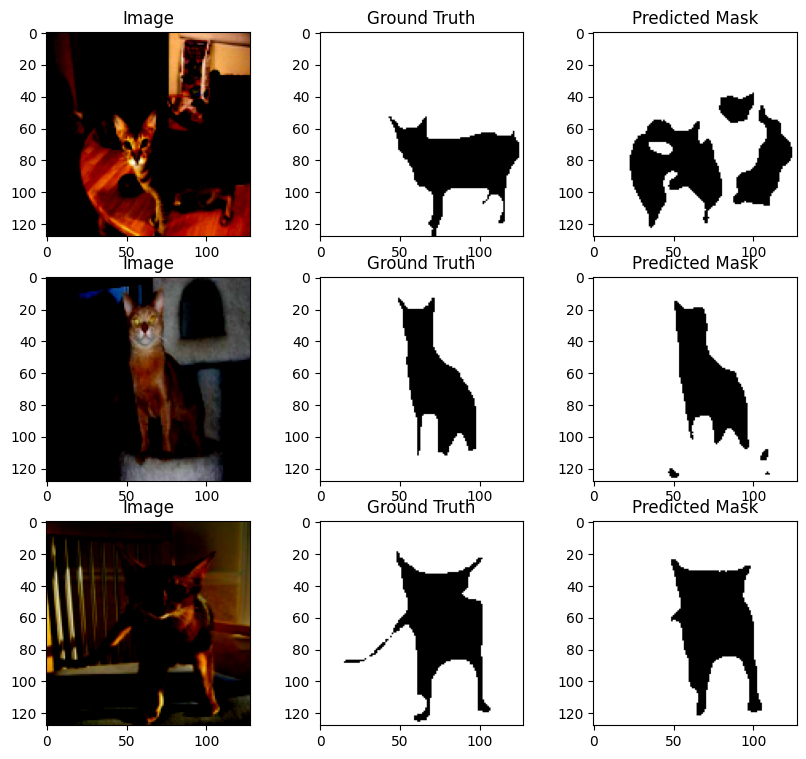

In [8]:
trainer.inference_and_plot_samples(n_samples=3)

Начинаем перебор гиперпараметров...

--- Тестируем LR: 0.001, Batch Size: 16 ---


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 46/46 [00:11<00:00,  3.85it/s]


Epoch 1 / 5, Train Loss: 0.4576, Val Loss: 0.5077, Val IoU: 0.7148, Val F1-score: 0.8288


100%|██████████| 46/46 [00:12<00:00,  3.80it/s]


Epoch 2 / 5, Train Loss: 0.3950, Val Loss: 0.3668, Val IoU: 0.7825, Val F1-score: 0.8729


...

Epoch 4 / 5, Train Loss: 0.4005, Val Loss: 0.3965, Val IoU: 0.8085, Val F1-score: 0.8884


100%|██████████| 12/12 [00:11<00:00,  1.01it/s]


Epoch 5 / 5, Train Loss: 0.3651, Val Loss: 0.3783, Val IoU: 0.8169, Val F1-score: 0.8929
Testing...


100%|██████████| 58/58 [01:01<00:00,  1.06s/it]

Test Loss: 0.3764, Test IoU: 0.8195, Test F1-score: 0.8942

Лучшие параметры: LR = 0.0001, Batch Size = 64
Лучший Validation IoU: 0.8633


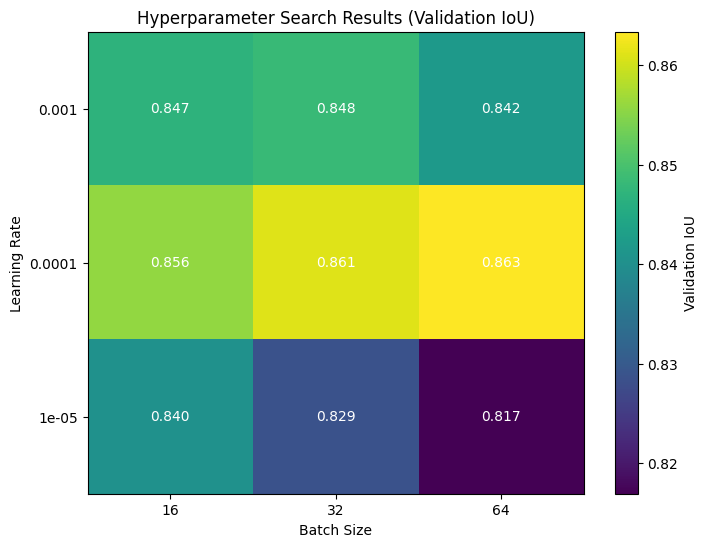

In [9]:
import itertools

# Настройки для перебора
lrs = [1e-3, 1e-4, 1e-5]
batch_sizes = [16, 32, 64]
search_epochs = 5 # Сокращаем количество эпох чисто для поиска

results = {}
best_iou = 0
best_params = None

print("Начинаем перебор гиперпараметров...")
for lr, bs in itertools.product(lrs, batch_sizes):
    print(f"\n--- Тестируем LR: {lr}, Batch Size: {bs} ---")

    # Обновляем конфиг
    config.learning_rate = lr
    config.batch_size = bs
    config.epochs = search_epochs
    config.use_batchnorm = True

    trainer = Trainer(config)
    history = trainer.run()

    # Берем лучший IoU на валидации за время обучения
    max_val_iou = max(history['val_iou'])
    results[(lr, bs)] = max_val_iou

    if max_val_iou > best_iou:
        best_iou = max_val_iou
        best_params = (lr, bs)

print(f"\nЛучшие параметры: LR = {best_params[0]}, Batch Size = {best_params[1]}")
print(f"Лучший Validation IoU: {best_iou:.4f}")

# График результатов перебора
lrs_str = [str(lr) for lr in lrs]
bs_str = [str(bs) for bs in batch_sizes]
heatmap_data = np.zeros((len(lrs), len(batch_sizes)))

for i, lr in enumerate(lrs):
    for j, bs in enumerate(batch_sizes):
        heatmap_data[i, j] = results[(lr, bs)]

plt.figure(figsize=(8, 6))
plt.imshow(heatmap_data, cmap='viridis', aspect='auto')
plt.colorbar(label='Validation IoU')
plt.xticks(ticks=np.arange(len(batch_sizes)), labels=bs_str)
plt.yticks(ticks=np.arange(len(lrs)), labels=lrs_str)
plt.xlabel('Batch Size')
plt.ylabel('Learning Rate')
plt.title('Hyperparameter Search Results (Validation IoU)')
for i in range(len(lrs)):
    for j in range(len(batch_sizes)):
        plt.text(j, i, f"{heatmap_data[i, j]:.3f}", ha="center", va="center", color="w")
plt.show()

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(



--- Обучение БЕЗ Batch Normalization ---


100%|██████████| 12/12 [00:12<00:00,  1.01s/it]


Epoch 1 / 15, Train Loss: 0.6307, Val Loss: 0.5856, Val IoU: 0.7020, Val F1-score: 0.8137


100%|██████████| 12/12 [00:12<00:00,  1.01s/it]


...

Epoch 14 / 15, Train Loss: 0.1290, Val Loss: 0.2415, Val IoU: 0.8754, Val F1-score: 0.9292


100%|██████████| 12/12 [00:12<00:00,  1.01s/it]


Epoch 15 / 15, Train Loss: 0.1201, Val Loss: 0.2333, Val IoU: 0.8749, Val F1-score: 0.9285
Testing...


100%|██████████| 58/58 [01:02<00:00,  1.08s/it]


Test Loss: 0.2281, Test IoU: 0.8768, Test F1-score: 0.9297


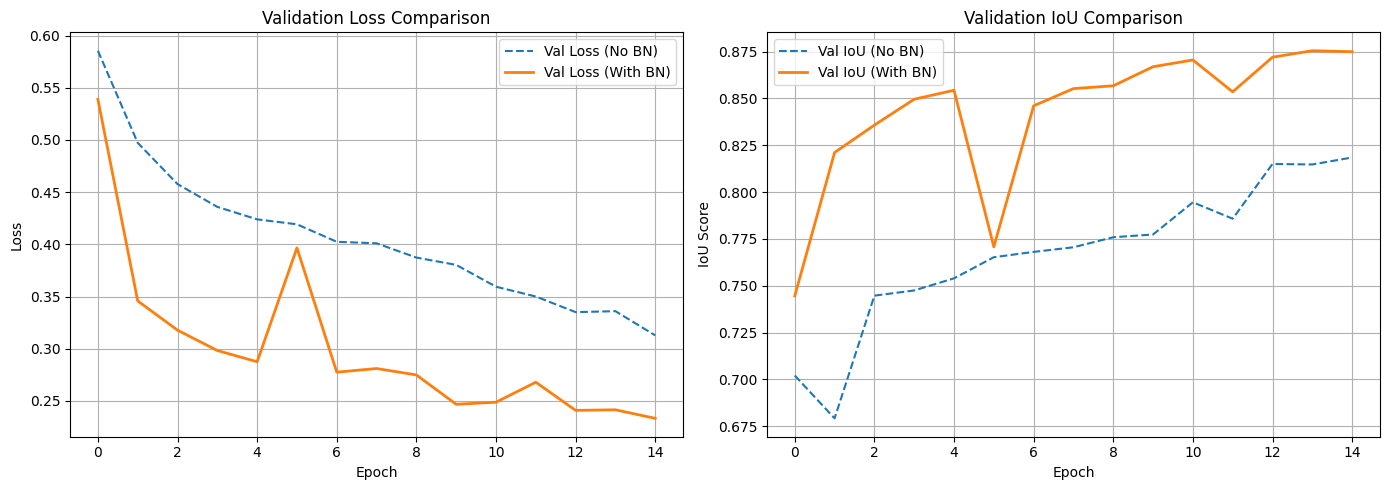

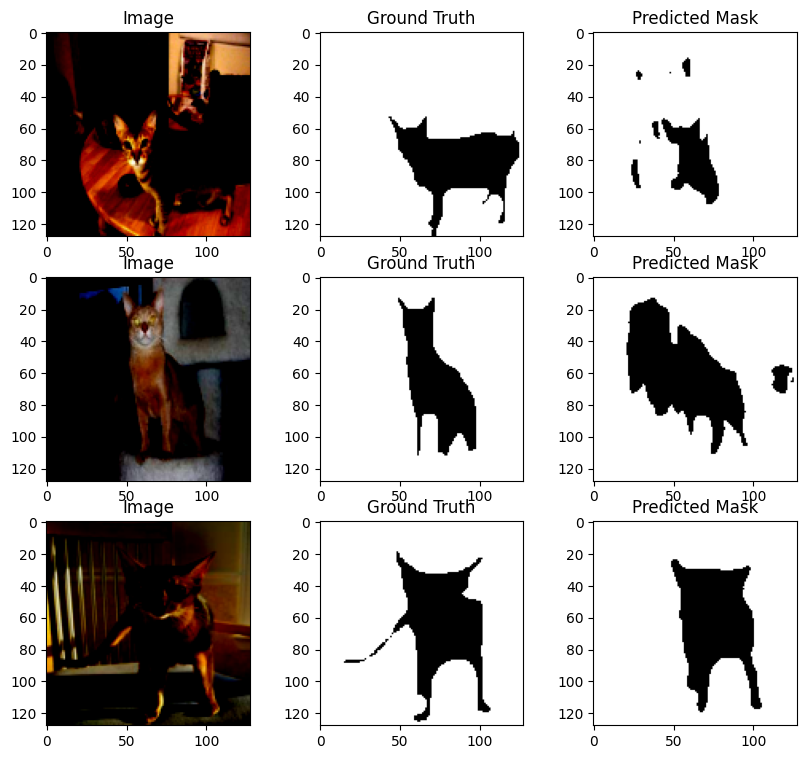

In [10]:
# Возвращаем нормальное количество эпох для финального сравнения
config.epochs = 15
config.learning_rate = best_params[0]
config.batch_size = best_params[1]

print("\n--- Обучение БЕЗ Batch Normalization ---")
config.use_batchnorm = False
trainer_no_bn = Trainer(config)
history_no_bn = trainer_no_bn.run()

print("\n--- Обучение С Batch Normalization ---")
config.use_batchnorm = True
trainer_with_bn = Trainer(config)
history_with_bn = trainer_with_bn.run()

# Строим графики сравнения
plt.figure(figsize=(14, 5))

# График Loss
plt.subplot(1, 2, 1)
plt.plot(history_no_bn['val_loss'], label='Val Loss (No BN)', linestyle='--')
plt.plot(history_with_bn['val_loss'], label='Val Loss (With BN)', linewidth=2)
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# График IoU
plt.subplot(1, 2, 2)
plt.plot(history_no_bn['val_iou'], label='Val IoU (No BN)', linestyle='--')
plt.plot(history_with_bn['val_iou'], label='Val IoU (With BN)', linewidth=2)
plt.title('Validation IoU Comparison')
plt.xlabel('Epoch')
plt.ylabel('IoU Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Вызов инференса для лучшей модели
trainer_with_bn.inference_and_plot_samples(n_samples=3)